# Annotation
Main driver of this analysis is simple curiosity. We asked ourselves: "what if we could analyse lyrics of one of the most influential artist of our generation?". This is how we decided to take as a project dataset of all lyrics of Kanye West's studio-recorded albums.

In [1]:
import pandas as pd

# Dataset creation
The dataset is generated using all Kanye West studio-recorded albums lyrics from https://www.kaggle.com/datasets/convolutionalnn/kanye-west-lyrics-dataset. Moreover, due to absence of the last 5 albums in the file, we had to copypaste their lyrics from https://genius.com. This data is located in data/raws. After parsing, it was  processed using Claude Cowork and resulted as data/jsons. Each file has has recordings about songs in the format "id, album, year, track, bonus, title, lyrics".

Extending topic of Claude cowork: to compile raw data we have prompted Claude to find titles of all songs in files and write them in the right format. Each file was then carefully checked and approved by ourselves.


In [2]:
cdjik = pd.read_json(r"data/jsons/CD_to_JIK.json").sort_values(["year", "track"])
donda1 = pd.read_json(r"data/jsons/donda_deluxe.json").sort_values(["year", "track"])
donda2 = pd.read_json(r"data/jsons/donda2.json").sort_values(["year", "track"])
vul1 = pd.read_json(r"data/jsons/vultures1.json").sort_values(["year", "track"])
vul2 = pd.read_json(r"data/jsons/vultures2.json").sort_values(["year", "track"])
bully = pd.read_json(r"data/jsons/bully.json").sort_values(["year", "track"])
raw = pd.concat([cdjik, donda1, donda2, vul1, vul2, bully], ignore_index=True)[cdjik.columns[1:]]
raw.head()


,album,year,track,bonus,title,lyrics
0,The College Dropout,2004,1,False,Intro,"[Intro: DeRay Davis]\nKanye, can I talk to you..."
1,The College Dropout,2004,2,False,We Don't Care,[Intro]\nOh yeah...\nI got the perfect song fo...
2,The College Dropout,2004,3,False,Graduation Day,"[Spoken: DeRay]\nWhat in the fuck was that, Ka..."
3,The College Dropout,2004,4,False,All Falls Down,"[Chorus: Syleena Johnson & Kanye West]\nOh, wh..."
4,The College Dropout,2004,5,False,I'll Fly Away,One glad morning\nWhen this life is over\nI'll...


In [3]:
raw.to_json(r'data/jsons/raw_full.json', orient="records", indent=2)

At this moment we have raw basic dataset that is ready to be cleaned up, explored, transformed and analysed.

# Cleaning
Let's check data for validity

In [4]:
report = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "non_null": raw.notna().sum().values,
    "null_pct": (raw.isna().mean() * 100).round(1).values,
    "nunique": raw.nunique(dropna=True).values,
})
print(report)

   column  dtype  non_null  null_pct  nunique
0   album    str       240       0.0       14
1    year  int64       240       0.0       13
2   track  int64       240       0.0       32
3   bonus   bool       240       0.0        2
4   title    str       240       0.0      239
5  lyrics    str       240       0.0      240


Superficial report shows that all datatypes are right, there is no Nan values. Moreover, all unique values are in the proper ranges, except, maybe title. Let's explore each column

In [5]:
# album
print(*raw["album"].unique(), sep="\n")

The College Dropout
Late Registration
Graduation
808s & Heartbreak
My Beautiful Dark Twisted Fantasy
Yeezus
The Life of Pablo
Ye
Jesus Is King
Donda (Deluxe)
Donda 2
Vultures 1
VULTURES 2
BULLY


All albums match the official titles.

In [6]:
# year
print(f"Year ranges from {raw["year"].min()} to {raw["year"].max()}")

Year ranges from 2004 to 2026


That coincides with official data

In [7]:
# title
duplicate_mask = raw["title"].duplicated(keep=False)
print(raw.loc[duplicate_mask].sort_values("title"))

          album  year  track  bonus title  \
175     Donda 2  2022     12  False   530   
212  VULTURES 2  2024     12  False   530   

                                                lyrics  
175  [Intro: Swsh]\nBaby, yeah\nWoah, baby\nWho pic...  
212  [Intro: Swsh]\nBaby, yeah\nWoah, baby, who pic...  


There is only one duplicated title in the list of songs and the song "530" with this title really does exist in both albums: Donda 2 and Vultures 2.

Now we want to explore the "lyrics" column and clean it up from all non-lyric symbols

In [8]:
lyrics = raw["lyrics"]
# print(lyrics[23])
# print(lyrics[46])
print(lyrics[57])
# print(lyrics[108])
# it seems like the only thing to remove is names of parts in brackets. for example:
# [Chorus]
# [Spoken Word: Max B & French Montana]
# [Intro: Mos Def]

[Intro: Mos Def]
I'm not sure anymore, more
Who is knocking at my door, door
All the faces that I know
Ja make them so sunny and true

[Chorus: Mos Def]
I don't wanna say goodbye, to you
So I'll just say good night, to you
My people, no goodbyes to you
I'm just gon' say good night

[Verse 1: Kanye West]
Uh
Good night
Right now I can see it so vivid
Like it was just yesterday, like I could relive it
Me and my grandparents on a field trip
And I'm the little kid tryna touch the exhibits
But it'll fade before I get to get a hold of that
Man, I wish I could stop time like a photograph
Every joke that they told I'd know to laugh
Man (man), I wouldn't let a moment pass
What do it mean when you dream that you fallin'?
What do it mean when you dream that you ballin'?
What do it mean when you never dream at all then
And you don't really know 'cause you can't recall them?
It's sorta fly you get a chance to say hi to
People you never got a chance to say bye to
Maybe you could pull em up outta your

In [9]:
import re
rep = r"\[([^\]]*)\]"
rep1 =r"[()]"
# clean["lyrics"] = clean["lyrics"].apply(lambda lyr: re.sub())
for i, row in raw.iterrows():
    findings = re.findall(rep, row["lyrics"])
    print(row["title"].upper(), f'({row["title"]})')
    print(*findings, sep='\n')
    print()

INTRO (Intro)
Intro: DeRay Davis

WE DON'T CARE (We Don't Care)
Intro
Chorus
Verse 1
Chorus
Verse 2
Chorus
Verse 3
Chorus

GRADUATION DAY (Graduation Day)
Spoken: DeRay
John Legend

ALL FALLS DOWN (All Falls Down)
Chorus: Syleena Johnson & Kanye West
Verse 1: Kanye West
Chorus: Syleena Johnson & Kanye West
Verse 2: Kanye West
Chorus: Syleena Johnson & Kanye West
Verse 3: Kanye West
Chorus: Syleena Johnson & Kanye West

I'LL FLY AWAY (I'll Fly Away)


SPACESHIP (Spaceship)
Chorus: John Legend
Verse 1: Kanye West
Chorus: John Legend
Verse 2: GLC
Chorus: John Legend
Verse 3: Consequence
Chorus: John Legend
Outro: Tony Williams

JESUS WALKS (Jesus Walks)
Intro
Chorus
Verse 1
Chorus
Verse 2
Chorus

NEVER LET ME DOWN (Never Let Me Down)
Chorus
Verse 1: Jay-Z
Chorus
Verse 2: Kanye West
Chorus
Verse 3: J. Ivy
Chorus
Verse 4: Jay-Z and (Kanye West)

GET EM HIGH (Get Em High)
Intro: Kanye West
Chorus: Kanye West
Verse 1: Kanye West
Chorus: Kanye West
Verse 2: Kanye West & Sumeke Rainey
Verse 3: 

Using this script we manually looked through the lyrics and all songs (except the "Last Call") has the same structure: set of songs parts of the form:
`"[{name of part}] {lyrics of part}"`

For example:
```
[Chorus: Mos Def]
I don't wanna say goodbye, to you
So I'll just say good night, to you
My people, no goodbyes to you
I'm just gon' say good night
```

But there wasone song -- "Last Call", where some lyrics were in square brackets. We've manually removed the brackets where it was necessary.

Now we can clean the data from square brackets and compare results

In [10]:
clean = raw.copy()
clean["lyrics"] = clean["lyrics"].apply(lambda lyr: re.sub(rep, "", lyr).strip())
clean["lyrics"] = clean["lyrics"].apply(lambda lyr: re.sub(rep1, "", lyr).strip())
n = 50
print("="*n, "RAW", "="*n)
print(*raw.query("title == 'Graduation Day'")["lyrics"].values)
print()
print()
print("="*n, "CLEAN", "="*n)
print(*clean.query("title == 'Graduation Day'")["lyrics"].values)

================================================== RAW ==================================================
[Spoken: DeRay]
What in the fuck was that, Kanye?! I told you to do some shit for the kids! You can give me your muthafuckin' graduation ticket right now! You give me this muthafuckin' robe before you catch some senioritis! You will not walk across that stage, you won’t slide across that stage! A muthafucka can’t pull you across that stage, Kanye! Who told you? See, I told you to do somethin' uplifting! I’m tryin' to get you out here with these white people and this how you're gonna do me! You know what, you's a nigga. And I don’t mean that in no nice way. Had little kids sing about the shit, the jokes on you. You throw your muthafuckin hands in the air, and wave good-bye to every-mothafuckin-body! Cause you gettin' the fuck out of this campus! What the fuck you gon' do now?

[John Legend]
I'm no longer confused, but don't tell anybody
I'm about to break the rules, but don't tell a

Now the dataset is clean. Before describing it we are left with some preparation work to do.
Firstly, we want to mark the songs that are too short, as too short songs may break the analysis.

                     title  word_counts
20               Last Call         2839
151        Jesus Lord Pt 2         1971
159             Jesus Lord         1456
136           Off the Grid         1349
110  No More Parties in LA         1170


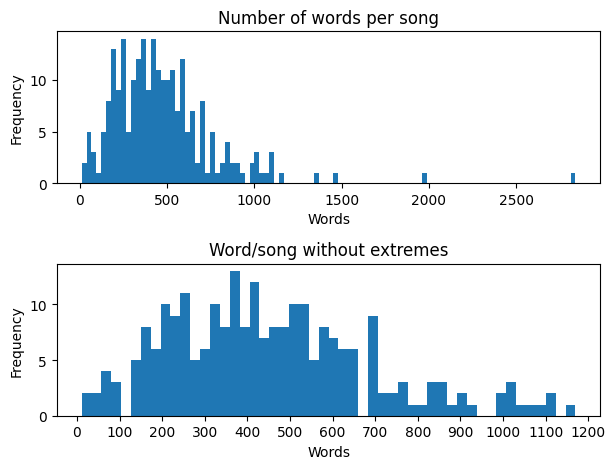

In [30]:
import matplotlib.pyplot as plt

clean["word_num"] = clean["lyrics"].apply(lambda x: len(x.split()))
print(clean.sort_values(["word_num"], ascending=False)[["title", "word_num"]].head(5))
#here we checked if all anomalies are really the valid songs with valid number of words.
# in fact, these are truly one of the longest Kanye's songs
fig, ax = plt.subplots(2)
# fig.set_figwidth(1000)
# fig.set_figheight(500)
ax[0].hist(clean["word_num"], bins=100, rwidth=1)
ax[0].set_xlabel("Words")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Number of words per song")

ax[1].hist(clean.query("word_num < 1300")["word_num"], bins=50, rwidth=1)
ax[1].set_xlabel("Words")
ax[1].set_ylabel("Frequency")
ax[1].set_xticks(range(0, 1300, 100))
ax[1].set_title("Word/song without extremes")
plt.tight_layout()
plt.show()

so we have about 100 words as the limit for the short words. Let's show this in the dataset

In [28]:
clean["short"] = clean["word_num"].apply(lambda x: x <=100)